In [2]:
# ==========================================
# 1. IMPORTING REQUIRED LIBRARIES
# ==========================================
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Set a beautiful, clean theme for all our visualizations
sns.set_theme(style="whitegrid", palette="muted")

print("Libraries imported successfully!")
print(f"Pandas version: {pd.__version__}")
print(f"Seaborn version: {sns.__version__}")

Libraries imported successfully!
Pandas version: 2.2.2
Seaborn version: 0.13.2


In [3]:
# ==========================================
# 2. LOADING THE DATASET
# ==========================================
# Load the dataset directly into a Pandas DataFrame
iris_df = sns.load_dataset('iris')

# If you were loading from a local file, the code would look like this:
# iris_df = pd.read_csv(r'C:\Users\YourName\Desktop\Dataset\Iris.csv')
# iris_df.drop(columns=["Id"], inplace=True) # Dropping 'Id' as it has no analytical value

print("Dataset successfully loaded into a Pandas DataFrame!")

Dataset successfully loaded into a Pandas DataFrame!


In [4]:
# ==========================================
# 3. BASIC DATA INSPECTION
# ==========================================
print("--- DATASET SHAPE ---")
# .shape returns a tuple: (Number of Rows, Number of Columns)
rows, cols = iris_df.shape
print(f"Total Rows (Samples): {rows}")
print(f"Total Columns (Features): {cols}\n")

print("--- COLUMN NAMES ---")
# .columns.tolist() gives us a clean list of the feature names
columns = iris_df.columns.tolist()
print(columns)
print("\n")

print("--- FIRST 5 ROWS (.head()) ---")
# .head() is crucial for a quick sanity check of the data values
display(iris_df.head())

--- DATASET SHAPE ---
Total Rows (Samples): 150
Total Columns (Features): 5

--- COLUMN NAMES ---
['sepal_length', 'sepal_width', 'petal_length', 'petal_width', 'species']


--- FIRST 5 ROWS (.head()) ---


,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


In [5]:
# ==========================================
# 4. DATASET INFORMATION
# ==========================================
print("--- DETAILED DATASET INFO ---")
# .info() provides a concise summary of the DataFrame
iris_df.info()

print("\n--- CHECKING FOR MISSING VALUES ---")
missing_values = iris_df.isnull().sum().sum()
if missing_values == 0:
    print(f"Great news! The dataset is completely clean with {missing_values} missing values.")
else:
    print(f"Warning: The dataset contains {missing_values} missing values.")

--- DETAILED DATASET INFO ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   sepal_length  150 non-null    float64
 1   sepal_width   150 non-null    float64
 2   petal_length  150 non-null    float64
 3   petal_width   150 non-null    float64
 4   species       150 non-null    object 
dtypes: float64(4), object(1)
memory usage: 6.0+ KB

--- CHECKING FOR MISSING VALUES ---
Great news! The dataset is completely clean with 0 missing values.


In [6]:
# ==========================================
# 5. STATISTICAL SUMMARY
# ==========================================
print("--- STATISTICAL SUMMARY OF NUMERICAL FEATURES ---")
summary_stats = iris_df.describe().round(2)
display(summary_stats)

print("\nUnderstanding the Metrics:")
print("- count : Total number of non-null values per column (150 for all, meaning no missing data).")
print("- mean  : The average value for each specific feature.")
print("- std   : Standard Deviation (how spread out the values are from the mean).")
print("- min   : The absolute smallest value observed.")
print("- 25%   : First Quartile (Q1) - 25% of the data falls below this value.")
print("- 50%   : Median (Q2) - The exact middle value of the data.")
print("- 75%   : Third Quartile (Q3) - 75% of the data falls below this value.")
print("- max   : The absolute largest value observed.")

--- STATISTICAL SUMMARY OF NUMERICAL FEATURES ---


,sepal_length,sepal_width,petal_length,petal_width
count,150.00,150.00,150.00,150.00
mean,5.84,3.06,3.76,1.20
std,0.83,0.44,1.77,0.76
min,4.30,2.00,1.00,0.10
25%,5.10,2.80,1.60,0.30
50%,5.80,3.00,4.35,1.30
75%,6.40,3.30,5.10,1.80
max,7.90,4.40,6.90,2.50



Understanding the Metrics:
- count : Total number of non-null values per column (150 for all, meaning no missing data).
- mean  : The average value for each specific feature.
- std   : Standard Deviation (how spread out the values are from the mean).
- min   : The absolute smallest value observed.
- 25%   : First Quartile (Q1) - 25% of the data falls below this value.
- 50%   : Median (Q2) - The exact middle value of the data.
- 75%   : Third Quartile (Q3) - 75% of the data falls below this value.
- max   : The absolute largest value observed.


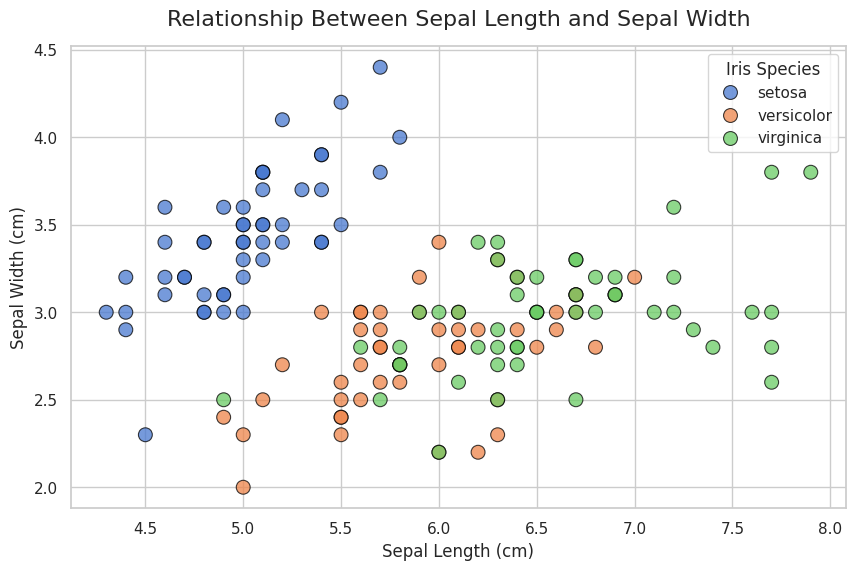

OBSERVATION (Sepal Features):
-> 'Setosa' (Blue) is clearly separated from the other two species, clustering in the top-left (shorter length, wider width).
-> 'Versicolor' and 'Virginica' are somewhat mixed together, making them harder to distinguish using only Sepal dimensions.



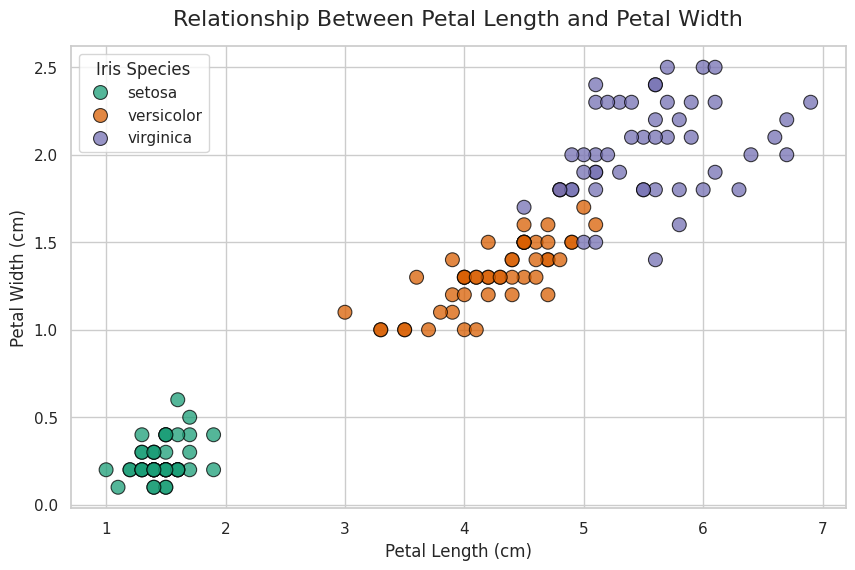

OBSERVATION (Petal Features):
-> All three species are clearly separated into distinct clusters.
-> Petal measurements are much stronger predictors for classifying Iris species than Sepal measurements.


In [7]:
# ==========================================
# 6. RELATIONSHIPS: SEPAL AND PETAL FEATURES
# ==========================================

# Plot 1: Sepal Features
plt.figure(figsize=(10, 6))
sns.scatterplot(data=iris_df, x="sepal_length", y="sepal_width", hue="species", s=100, alpha=0.75, edgecolor='black')
plt.title("Relationship Between Sepal Length and Sepal Width", fontsize=16, pad=15)
plt.xlabel("Sepal Length (cm)", fontsize=12)
plt.ylabel("Sepal Width (cm)", fontsize=12)
plt.legend(title="Iris Species", fontsize=11)
plt.show()

print("OBSERVATION (Sepal Features):")
print("-> 'Setosa' (Blue) is clearly separated from the other two species, clustering in the top-left (shorter length, wider width).")
print("-> 'Versicolor' and 'Virginica' are somewhat mixed together, making them harder to distinguish using only Sepal dimensions.\n")

# Plot 2: Petal Features
plt.figure(figsize=(10, 6))
sns.scatterplot(data=iris_df, x="petal_length", y="petal_width", hue="species", s=100, alpha=0.75, edgecolor='black', palette="Dark2")
plt.title("Relationship Between Petal Length and Petal Width", fontsize=16, pad=15)
plt.xlabel("Petal Length (cm)", fontsize=12)
plt.ylabel("Petal Width (cm)", fontsize=12)
plt.legend(title="Iris Species", fontsize=11)
plt.show()

print("OBSERVATION (Petal Features):")
print("-> All three species are clearly separated into distinct clusters.")
print("-> Petal measurements are much stronger predictors for classifying Iris species than Sepal measurements.")

Generating Pair Plot... (This may take a few seconds)


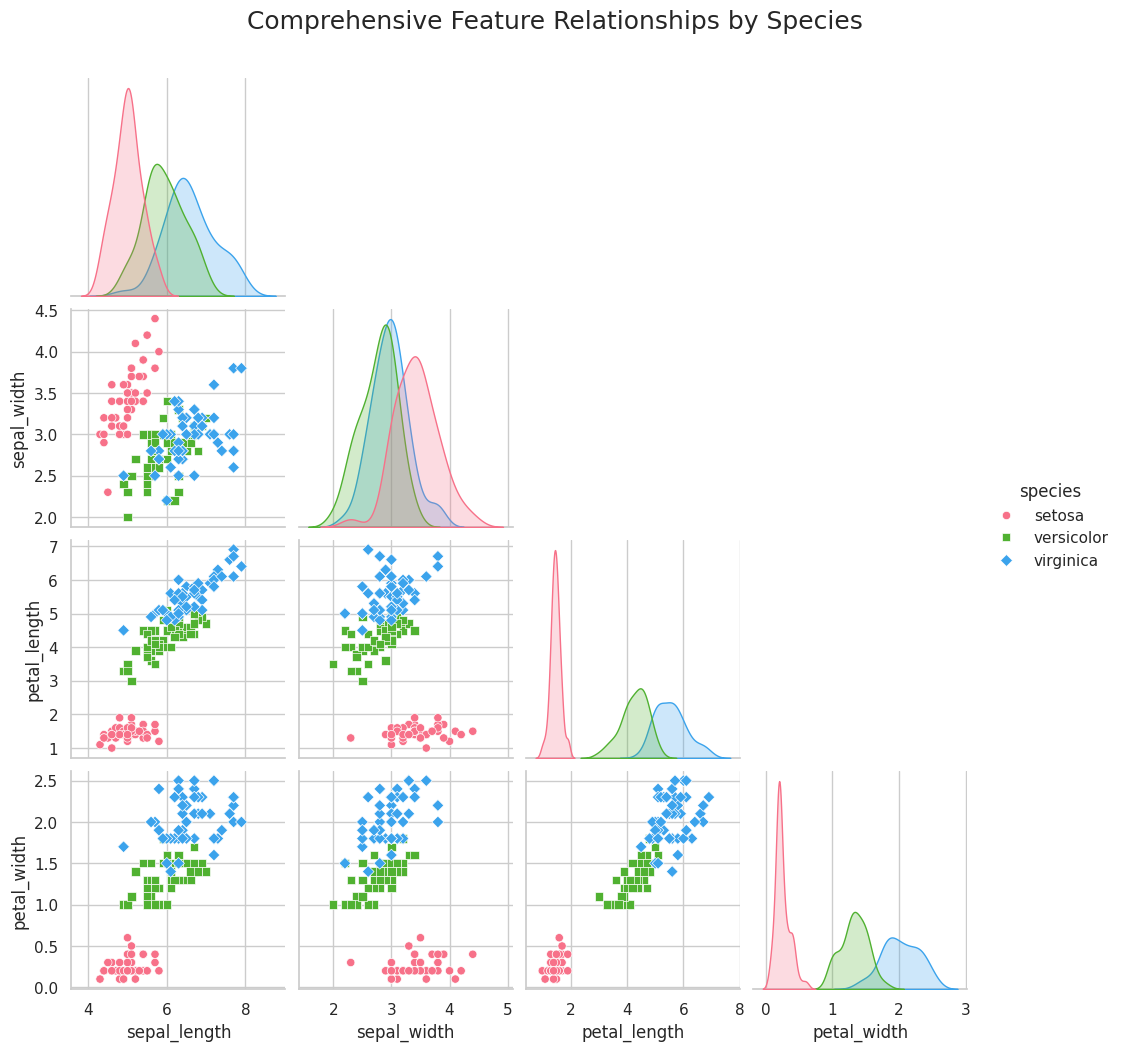

OBSERVATION (Pair Plot):
-> The diagonal shows the density distribution of each feature.
-> We can easily confirm that anytime Petal Length or Petal Width is involved in the scatter plot, the species separate beautifully.


In [8]:
# ==========================================
# 7. COMPREHENSIVE PAIR PLOT
# ==========================================
print("Generating Pair Plot... (This may take a few seconds)")
pair_plot = sns.pairplot(iris_df, hue="species", markers=["o", "s", "D"], palette="husl", corner=True)
pair_plot.fig.suptitle("Comprehensive Feature Relationships by Species", y=1.05, fontsize=18)
plt.show()

print("OBSERVATION (Pair Plot):")
print("-> The diagonal shows the density distribution of each feature.")
print("-> We can easily confirm that anytime Petal Length or Petal Width is involved in the scatter plot, the species separate beautifully.")

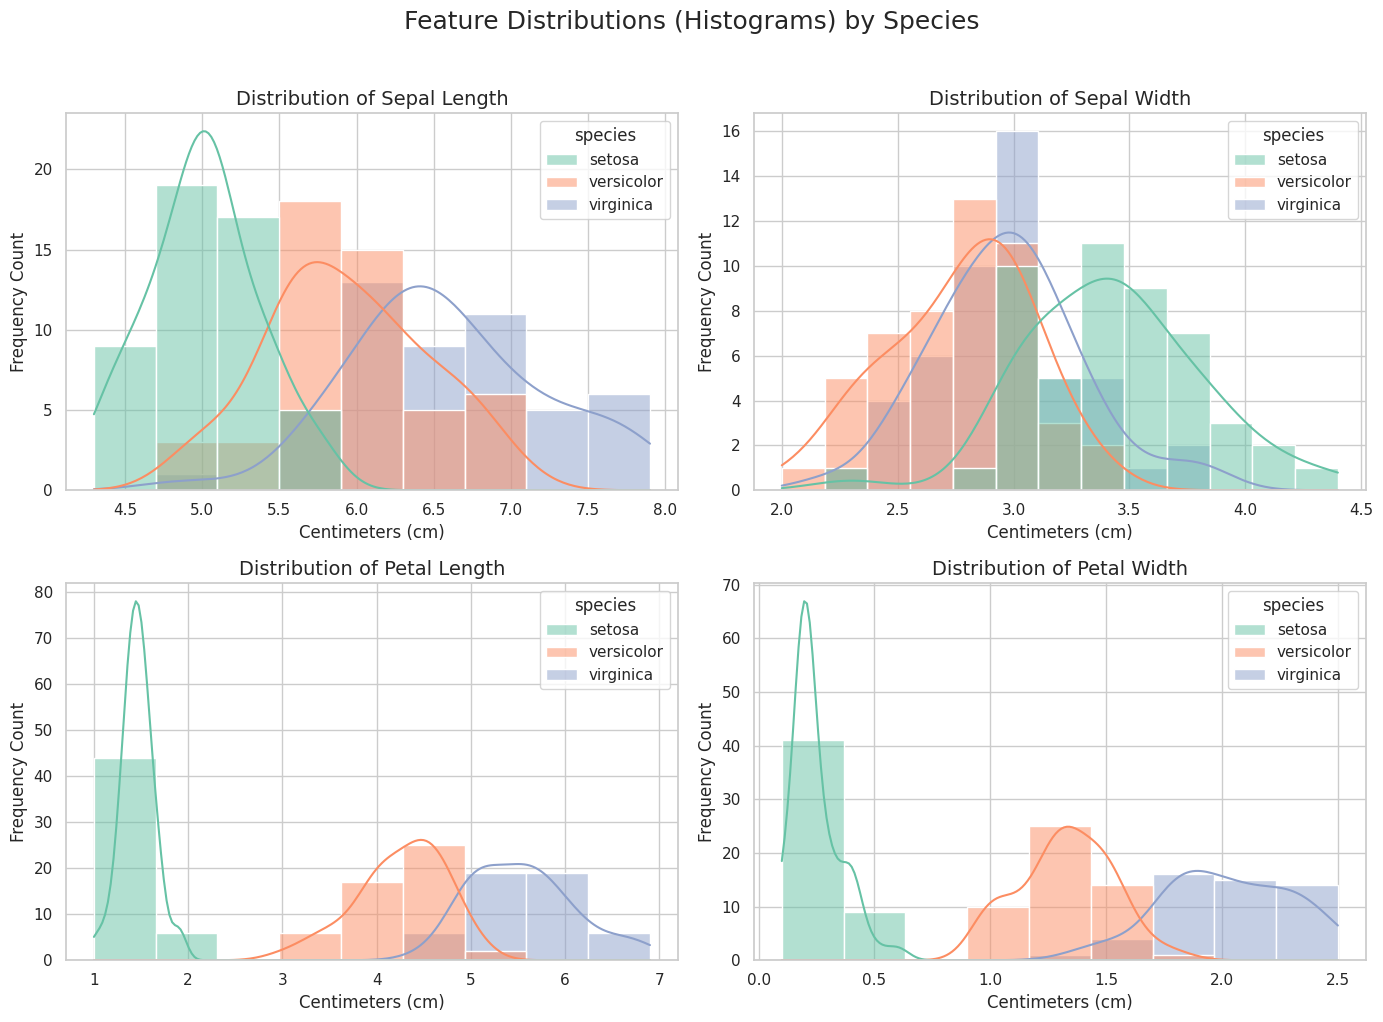

OBSERVATION (Distributions):
-> Sepal Width follows a relatively normal (bell-curve) distribution.
-> Petal Length and Petal Width exhibit 'Bimodal' distributions (two distinct peaks). One peak belongs entirely to Setosa (small values), and the broader peak belongs to Versicolor/Virginica.


In [9]:
# ==========================================
# 8. DATA DISTRIBUTION: HISTOGRAMS
# ==========================================
# Create a 2x2 grid for subplots
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle("Feature Distributions (Histograms) by Species", fontsize=18, y=1.02)

features = ['sepal_length', 'sepal_width', 'petal_length', 'petal_width']

for i, feature in enumerate(features):
    row = i // 2  # integer division to get row index (0 or 1)
    col = i % 2   # modulo to get column index (0 or 1)

    sns.histplot(data=iris_df, x=feature, hue="species", kde=True, ax=axes[row, col], palette="Set2")
    axes[row, col].set_title(f"Distribution of {feature.replace('_', ' ').title()}", fontsize=14)
    axes[row, col].set_xlabel("Centimeters (cm)")
    axes[row, col].set_ylabel("Frequency Count")

plt.tight_layout()
plt.show()

print("OBSERVATION (Distributions):")
print("-> Sepal Width follows a relatively normal (bell-curve) distribution.")
print("-> Petal Length and Petal Width exhibit 'Bimodal' distributions (two distinct peaks). One peak belongs entirely to Setosa (small values), and the broader peak belongs to Versicolor/Virginica.")

/tmp/ipykernel_6024/1769675650.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='species', y=feature, data=iris_df, palette="Pastel1", linewidth=1.5)
/tmp/ipykernel_6024/1769675650.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='species', y=feature, data=iris_df, palette="Pastel1", linewidth=1.5)
/tmp/ipykernel_6024/1769675650.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='species', y=feature, data=iris_df, palette="Pastel1", linewidth=1.5)
/tmp/ipykernel_6024/1769675650.py:9: FutureWarning: 

Passing `palette` without as

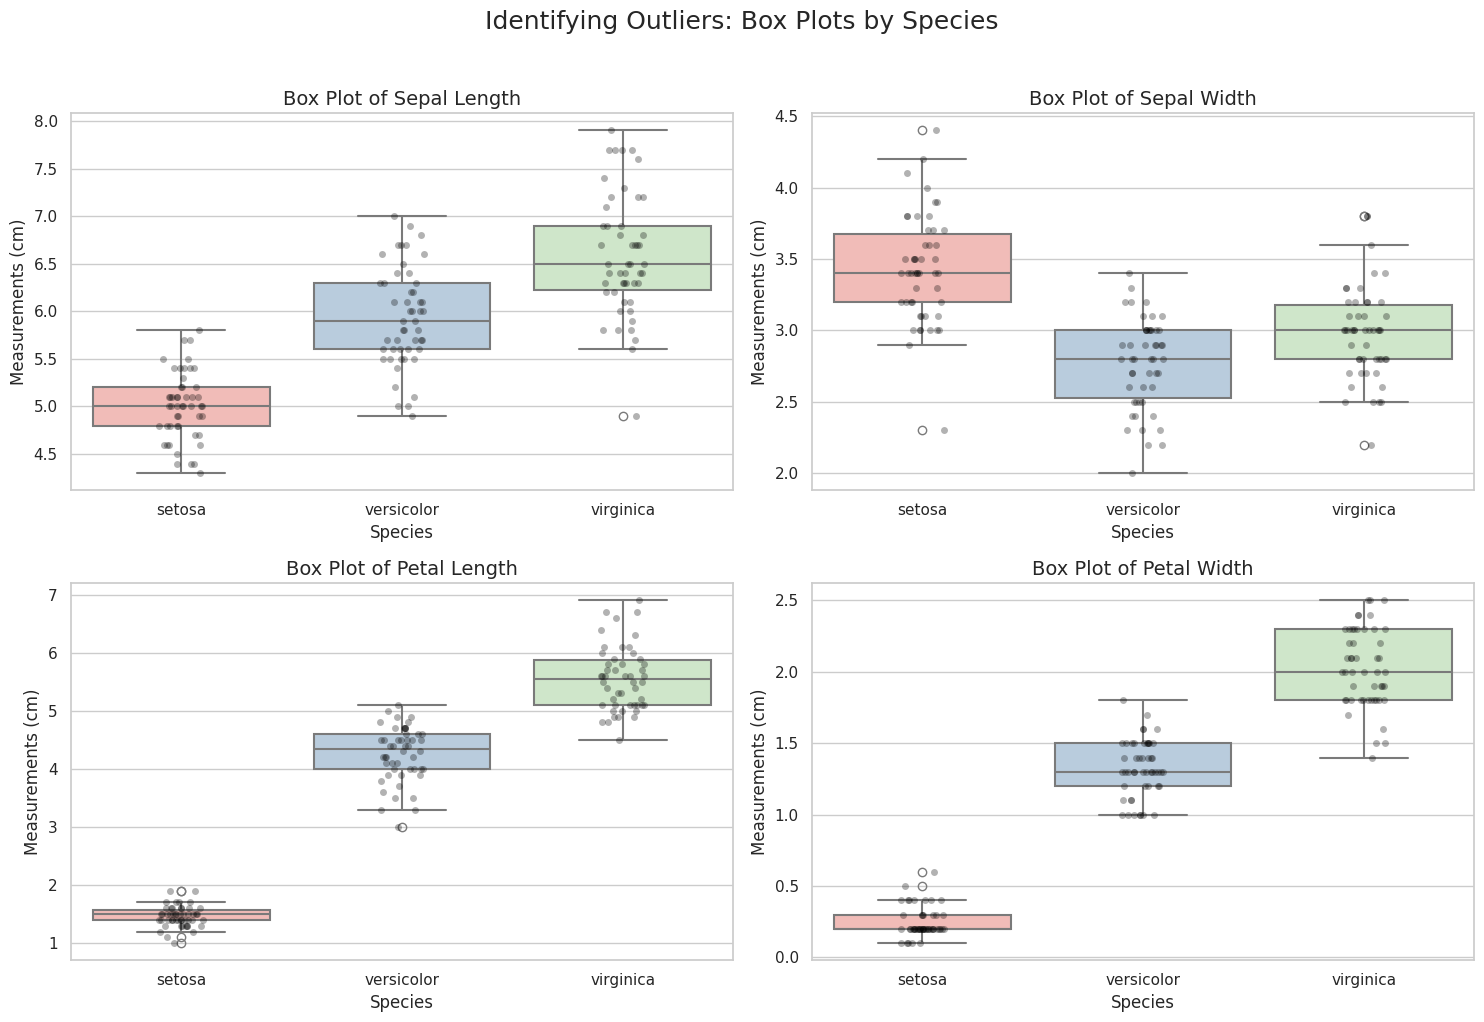

OBSERVATION (Outliers):
-> Sepal Length: Mostly clean. Only one very minor outlier in Virginica.
-> Sepal Width: Contains the most outliers (visible as dots outside the whiskers in Virginica and Setosa).
-> Petal Length: Clean data. Minor outliers in Setosa and Versicolor.
-> Petal Width: Clean data. Minor outliers in Setosa.
Overall, the dataset is exceptionally clean and does not require intense outlier treatment.


In [10]:
# ==========================================
# 9. OUTLIER DETECTION: BOX PLOTS
# ==========================================
plt.figure(figsize=(15, 10))
plt.suptitle('Identifying Outliers: Box Plots by Species', fontsize=18, y=1.02)

for i, feature in enumerate(features):
    plt.subplot(2, 2, i + 1)
    sns.boxplot(x='species', y=feature, data=iris_df, palette="Pastel1", linewidth=1.5)

    # Adding a stripplot on top of the boxplot to show the actual data points
    sns.stripplot(x='species', y=feature, data=iris_df, color='black', alpha=0.3, jitter=True)

    plt.title(f'Box Plot of {feature.replace("_", " ").title()}', fontsize=14)
    plt.xlabel('Species', fontsize=12)
    plt.ylabel('Measurements (cm)', fontsize=12)

plt.tight_layout()
plt.show()

print("OBSERVATION (Outliers):")
print("-> Sepal Length: Mostly clean. Only one very minor outlier in Virginica.")
print("-> Sepal Width: Contains the most outliers (visible as dots outside the whiskers in Virginica and Setosa).")
print("-> Petal Length: Clean data. Minor outliers in Setosa and Versicolor.")
print("-> Petal Width: Clean data. Minor outliers in Setosa.")
print("Overall, the dataset is exceptionally clean and does not require intense outlier treatment.")